In [3]:
!pwd

/home/manish/work/SystemDesign/SpdkKeyValueStore/tests/e2e


,Server,Total Requests,Concurrency,Total Time (s),Average Latency (ms),Fastest (ms),Slowest (ms),RPS,P50 (ms),P90 (ms),P99 (ms)
0,C++,2000,100,122.10,4457.70,503.48,23779.76,16379.37,3837.05,7377.85,16596.87
1,C++,2000,100,113.17,3867.67,477.99,18433.86,17671.89,3690.71,5513.49,12777.09
2,C++,2000,100,108.49,3910.26,489.44,14628.98,18435.17,3680.13,5744.74,10399.02
3,Go,2000,100,98.78,3431.88,236.62,16000.33,20247.19,3193.50,4988.82,9200.67
4,Go,2000,100,108.42,3625.25,204.28,16402.94,18446.23,3369.78,5129.22,9015.90
5,Go,2000,100,108.20,3576.73,587.70,16262.37,18485.08,3382.51,4790.13,11935.07


,Average Latency (ms),Fastest (ms),Slowest (ms),RPS,P50 (ms),P90 (ms),P99 (ms)
Server,,,,,,,
C++,4078.543333,490.303333,18947.533333,17495.476667,3735.963333,6212.026667,13257.660000
Go,3544.620000,342.866667,16221.880000,19059.500000,3315.263333,4969.390000,10050.546667


<Figure size 800x400 with 0 Axes>

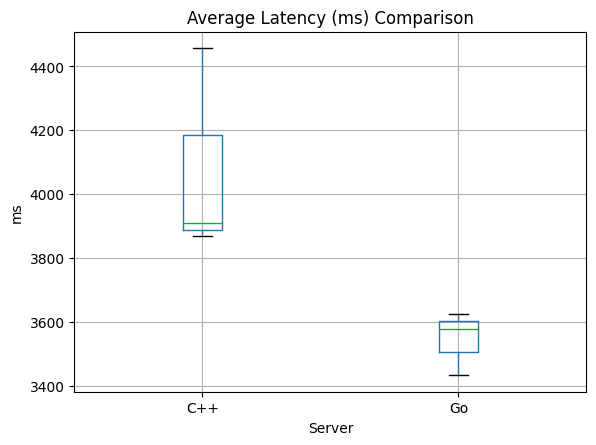

<Figure size 800x400 with 0 Axes>

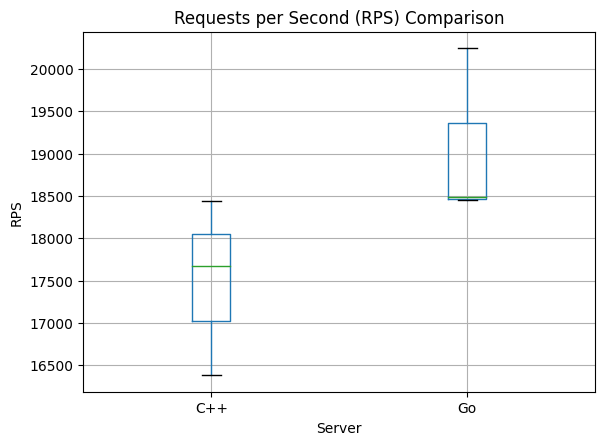

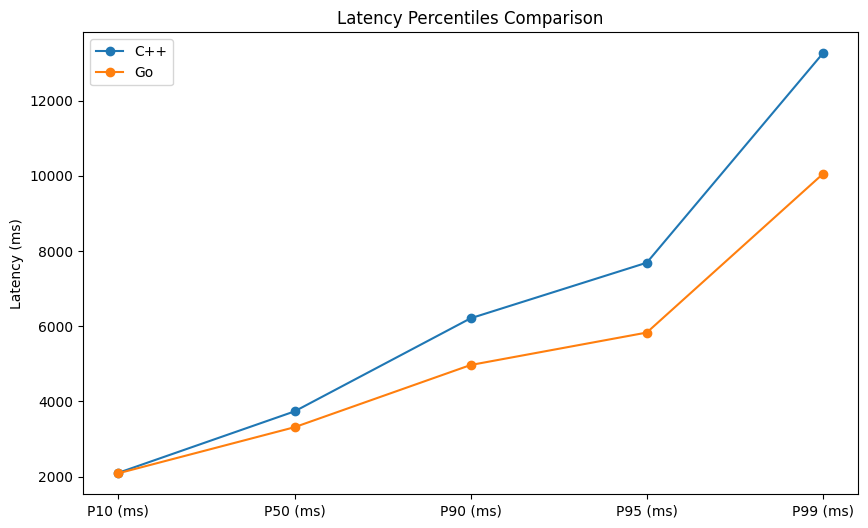

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSVs
cpp = pd.read_csv('../benchmark/results/benchmark_results_2025-06-14_19-17-47_cpp_std_map.csv')
go = pd.read_csv('../benchmark/results/benchmark_results_2025-06-14_19-10-13_goserver.csv')

# Add label for source
cpp['Server'] = 'C++'
go['Server'] = 'Go'

# Combine
df = pd.concat([cpp, go], ignore_index=True)

# Clean columns if needed (sometimes 'Unnamed' column comes in)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Show side-by-side comparison
display(df[['Server', 'Total Requests', 'Concurrency', 'Total Time (s)', 'Average Latency (ms)', 
            'Fastest (ms)', 'Slowest (ms)', 'RPS', 'P50 (ms)', 'P90 (ms)', 'P99 (ms)']])

# Group by server and get mean (since you have 3 runs each)
summary = df.groupby('Server').mean(numeric_only=True)
display(summary[['Average Latency (ms)', 'Fastest (ms)', 'Slowest (ms)', 'RPS', 'P50 (ms)', 'P90 (ms)', 'P99 (ms)']])

# Boxplot: Average Latency per Server
plt.figure(figsize=(8, 4))
df.boxplot(column='Average Latency (ms)', by='Server')
plt.title('Average Latency (ms) Comparison')
plt.suptitle('')
plt.ylabel('ms')
plt.show()

# Boxplot: RPS per Server
plt.figure(figsize=(8, 4))
df.boxplot(column='RPS', by='Server')
plt.title('Requests per Second (RPS) Comparison')
plt.suptitle('')
plt.ylabel('RPS')
plt.show()

# Percentile plots
percentiles = ['P10 (ms)', 'P50 (ms)', 'P90 (ms)', 'P95 (ms)', 'P99 (ms)']
plt.figure(figsize=(10, 6))
for srv in ['C++', 'Go']:
    vals = df[df['Server']==srv][percentiles].mean()
    plt.plot(percentiles, vals, marker='o', label=srv)
plt.title('Latency Percentiles Comparison')
plt.ylabel('Latency (ms)')
plt.legend()
plt.show()


,Server,Total Requests,Concurrency,Total Time (s),Average Latency (ms),Fastest (ms),Slowest (ms),RPS,P50 (ms),P90 (ms),P99 (ms)
0,C++,2000,1000,88.13,31089.85,5112.02,76749.59,22694.18,31989.42,49037.17,71706.13
1,C++,2000,1000,88.49,27855.37,6709.57,69555.71,22601.06,28326.20,43190.72,53878.33
2,C++,2000,1000,133.03,48516.29,9458.56,119621.81,15033.88,40565.40,92992.60,114451.86
3,Go,2000,1000,81.10,21376.13,6258.06,78645.58,24660.72,18972.01,28909.55,71691.79
4,Go,2000,1000,82.58,29269.37,4945.62,72808.01,24218.97,26814.38,49546.31,63912.99
5,Go,2000,1000,103.54,36637.59,5472.52,83980.64,19316.64,29373.86,68898.71,79900.05


,Average Latency (ms),Fastest (ms),Slowest (ms),RPS,P50 (ms),P90 (ms),P99 (ms)
Server,,,,,,,
C++,35820.503333,7093.383333,88642.370000,20109.706667,33627.006667,61740.163333,80012.106667
Go,29094.363333,5558.733333,78478.076667,22732.110000,25053.416667,49118.190000,71834.943333


<Figure size 800x400 with 0 Axes>

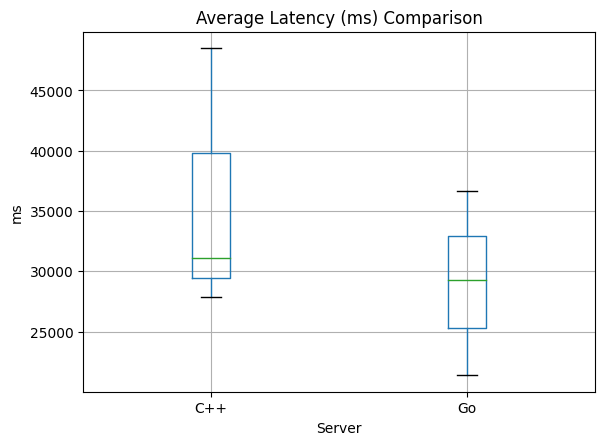

<Figure size 800x400 with 0 Axes>

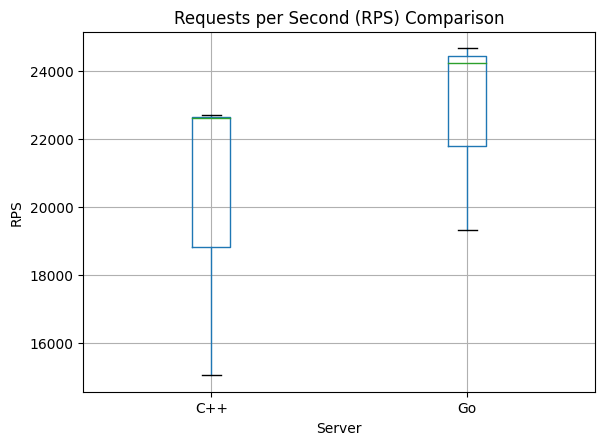

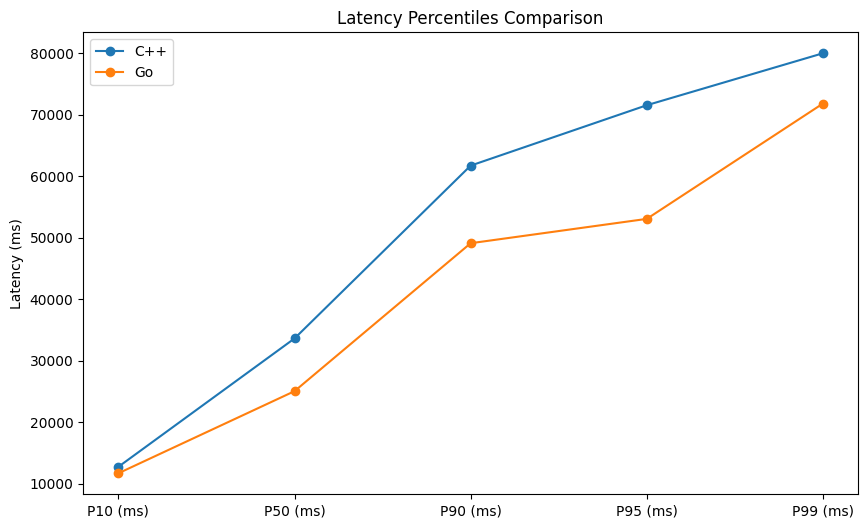

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSVs
cpp = pd.read_csv('../benchmark/results/benchmark_results_2025-06-14_19-27-17_cpp.csv')
go = pd.read_csv('../benchmark/results/benchmark_results_2025-06-14_19-28-06_go.csv')

# Add label for source
cpp['Server'] = 'C++'
go['Server'] = 'Go'

# Combine
df = pd.concat([cpp, go], ignore_index=True)

# Clean columns if needed (sometimes 'Unnamed' column comes in)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Show side-by-side comparison
display(df[['Server', 'Total Requests', 'Concurrency', 'Total Time (s)', 'Average Latency (ms)', 
            'Fastest (ms)', 'Slowest (ms)', 'RPS', 'P50 (ms)', 'P90 (ms)', 'P99 (ms)']])

# Group by server and get mean (since you have 3 runs each)
summary = df.groupby('Server').mean(numeric_only=True)
display(summary[['Average Latency (ms)', 'Fastest (ms)', 'Slowest (ms)', 'RPS', 'P50 (ms)', 'P90 (ms)', 'P99 (ms)']])

# Boxplot: Average Latency per Server
plt.figure(figsize=(8, 4))
df.boxplot(column='Average Latency (ms)', by='Server')
plt.title('Average Latency (ms) Comparison')
plt.suptitle('')
plt.ylabel('ms')
plt.show()

# Boxplot: RPS per Server
plt.figure(figsize=(8, 4))
df.boxplot(column='RPS', by='Server')
plt.title('Requests per Second (RPS) Comparison')
plt.suptitle('')
plt.ylabel('RPS')
plt.show()

# Percentile plots
percentiles = ['P10 (ms)', 'P50 (ms)', 'P90 (ms)', 'P95 (ms)', 'P99 (ms)']
plt.figure(figsize=(10, 6))
for srv in ['C++', 'Go']:
    vals = df[df['Server']==srv][percentiles].mean()
    plt.plot(percentiles, vals, marker='o', label=srv)
plt.title('Latency Percentiles Comparison')
plt.ylabel('Latency (ms)')
plt.legend()
plt.show()


In [9]:
summary[['Average Latency (ms)', 'Fastest (ms)', 'Slowest (ms)', 'RPS', 'P50 (ms)', 'P90 (ms)', 'P99 (ms)']]

,Average Latency (ms),Fastest (ms),Slowest (ms),RPS,P50 (ms),P90 (ms),P99 (ms)
Server,,,,,,,
C++,35820.503333,7093.383333,88642.370000,20109.706667,33627.006667,61740.163333,80012.106667
Go,29094.363333,5558.733333,78478.076667,22732.110000,25053.416667,49118.190000,71834.943333


,Server,Total Requests,Concurrency,Total Time (s),Average Latency (ms),Fastest (ms),Slowest (ms),RPS,P50 (ms),P90 (ms),P99 (ms)
0,C++,2000,1000,101.67,37649.94,5107.92,83314.43,19671.42,37038.97,60690.90,81197.21
1,C++,2000,1000,80.61,26298.40,10662.36,64848.83,24809.90,24867.35,38659.26,49829.41
2,C++,2000,1000,85.66,24328.85,6666.34,62236.91,23347.98,22701.57,41839.17,54881.44
3,Go,2000,1000,81.10,21376.13,6258.06,78645.58,24660.72,18972.01,28909.55,71691.79
4,Go,2000,1000,82.58,29269.37,4945.62,72808.01,24218.97,26814.38,49546.31,63912.99
5,Go,2000,1000,103.54,36637.59,5472.52,83980.64,19316.64,29373.86,68898.71,79900.05


,Average Latency (ms),Fastest (ms),Slowest (ms),RPS,P50 (ms),P90 (ms),P99 (ms)
Server,,,,,,,
C++,29425.730000,7478.873333,70133.390000,22609.766667,28202.630000,47063.11,61969.353333
Go,29094.363333,5558.733333,78478.076667,22732.110000,25053.416667,49118.19,71834.943333


<Figure size 800x400 with 0 Axes>

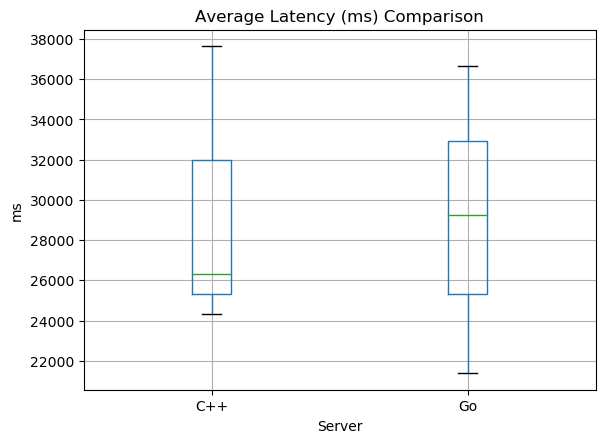

<Figure size 800x400 with 0 Axes>

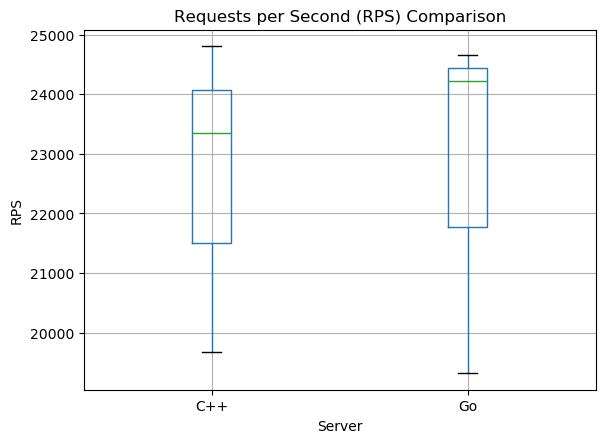

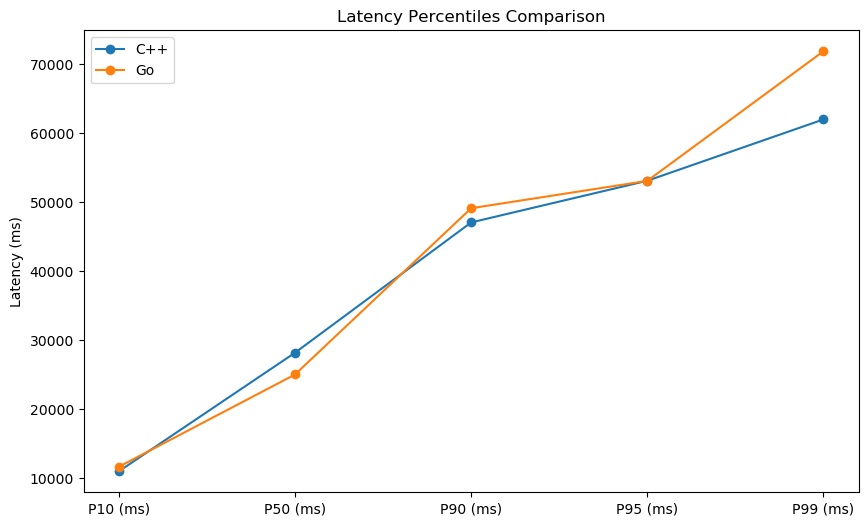

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSVs
cpp = pd.read_csv('../benchmark/results/benchmark_results_2025-06-15_12-42-00_cpp_folly_just_skiplist_async_grpc.csv')
go = pd.read_csv('../benchmark/results/benchmark_results_2025-06-14_19-28-06_go.csv')

# Add label for source
cpp['Server'] = 'C++'
go['Server'] = 'Go'

# Combine
df = pd.concat([cpp, go], ignore_index=True)

# Clean columns if needed (sometimes 'Unnamed' column comes in)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Show side-by-side comparison
display(df[['Server', 'Total Requests', 'Concurrency', 'Total Time (s)', 'Average Latency (ms)', 
            'Fastest (ms)', 'Slowest (ms)', 'RPS', 'P50 (ms)', 'P90 (ms)', 'P99 (ms)']])

# Group by server and get mean (since you have 3 runs each)
summary = df.groupby('Server').mean(numeric_only=True)
display(summary[['Average Latency (ms)', 'Fastest (ms)', 'Slowest (ms)', 'RPS', 'P50 (ms)', 'P90 (ms)', 'P99 (ms)']])

# Boxplot: Average Latency per Server
plt.figure(figsize=(8, 4))
df.boxplot(column='Average Latency (ms)', by='Server')
plt.title('Average Latency (ms) Comparison')
plt.suptitle('')
plt.ylabel('ms')
plt.show()

# Boxplot: RPS per Server
plt.figure(figsize=(8, 4))
df.boxplot(column='RPS', by='Server')
plt.title('Requests per Second (RPS) Comparison')
plt.suptitle('')
plt.ylabel('RPS')
plt.show()

# Percentile plots
percentiles = ['P10 (ms)', 'P50 (ms)', 'P90 (ms)', 'P95 (ms)', 'P99 (ms)']
plt.figure(figsize=(10, 6))
for srv in ['C++', 'Go']:
    vals = df[df['Server']==srv][percentiles].mean()
    plt.plot(percentiles, vals, marker='o', label=srv)
plt.title('Latency Percentiles Comparison')
plt.ylabel('Latency (ms)')
plt.legend()
plt.show()


,Server,Total Requests,Concurrency,Total Time (s),Average Latency (ms),Fastest (ms),Slowest (ms),RPS,P50 (ms),P90 (ms),P99 (ms)
0,C++,2000,1000,101.67,37649.94,5107.92,83314.43,19671.42,37038.97,60690.90,81197.21
1,C++,2000,1000,80.61,26298.40,10662.36,64848.83,24809.90,24867.35,38659.26,49829.41
2,C++,2000,1000,85.66,24328.85,6666.34,62236.91,23347.98,22701.57,41839.17,54881.44
3,Go,2000,1000,81.10,21376.13,6258.06,78645.58,24660.72,18972.01,28909.55,71691.79
4,Go,2000,1000,82.58,29269.37,4945.62,72808.01,24218.97,26814.38,49546.31,63912.99
5,Go,2000,1000,103.54,36637.59,5472.52,83980.64,19316.64,29373.86,68898.71,79900.05


,Average Latency (ms),Fastest (ms),Slowest (ms),RPS,P50 (ms),P90 (ms),P99 (ms)
Server,,,,,,,
C++,29425.730000,7478.873333,70133.390000,22609.766667,28202.630000,47063.11,61969.353333
Go,29094.363333,5558.733333,78478.076667,22732.110000,25053.416667,49118.19,71834.943333


<Figure size 800x400 with 0 Axes>

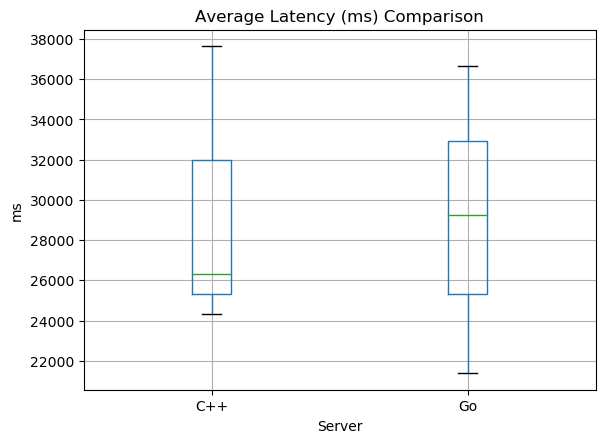

<Figure size 800x400 with 0 Axes>

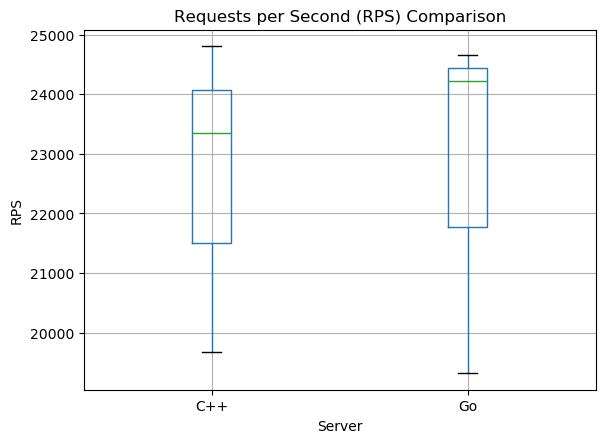

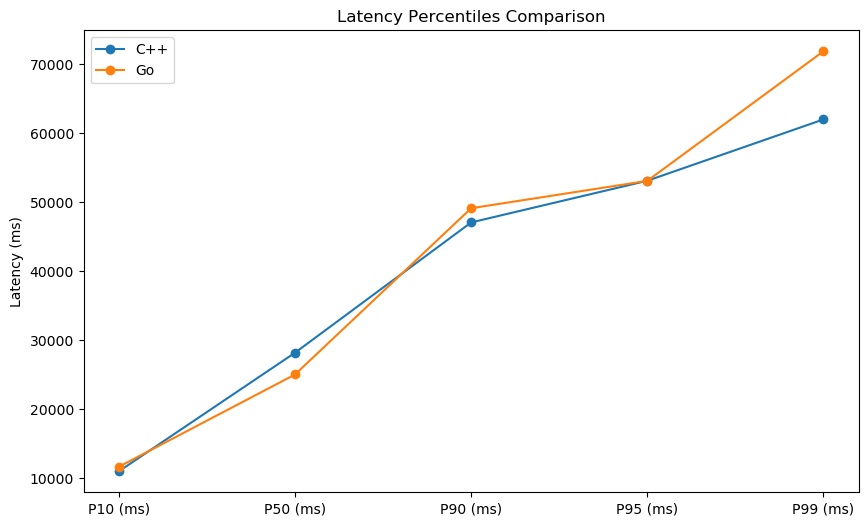

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSVs
cpp = pd.read_csv('../benchmark/results/server_cpp_results.csv')
go = pd.read_csv('../benchmark/results/server_golang_results.csv')

# Add label for source
cpp['Server'] = 'C++'
go['Server'] = 'Go'

# Combine
df = pd.concat([cpp, go], ignore_index=True)

# Clean columns if needed (sometimes 'Unnamed' column comes in)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Show side-by-side comparison
display(df[['Server', 'Total Requests', 'Concurrency', 'Total Time (s)', 'Average Latency (ms)', 
            'Fastest (ms)', 'Slowest (ms)', 'RPS', 'P50 (ms)', 'P90 (ms)', 'P99 (ms)']])

# Group by server and get mean (since you have 3 runs each)
summary = df.groupby('Server').mean(numeric_only=True)
display(summary[['Average Latency (ms)', 'Fastest (ms)', 'Slowest (ms)', 'RPS', 'P50 (ms)', 'P90 (ms)', 'P99 (ms)']])

# Boxplot: Average Latency per Server
plt.figure(figsize=(8, 4))
df.boxplot(column='Average Latency (ms)', by='Server')
plt.title('Average Latency (ms) Comparison')
plt.suptitle('')
plt.ylabel('ms')
plt.show()

# Boxplot: RPS per Server
plt.figure(figsize=(8, 4))
df.boxplot(column='RPS', by='Server')
plt.title('Requests per Second (RPS) Comparison')
plt.suptitle('')
plt.ylabel('RPS')
plt.show()

# Percentile plots
percentiles = ['P10 (ms)', 'P50 (ms)', 'P90 (ms)', 'P95 (ms)', 'P99 (ms)']
plt.figure(figsize=(10, 6))
for srv in ['C++', 'Go']:
    vals = df[df['Server']==srv][percentiles].mean()
    plt.plot(percentiles, vals, marker='o', label=srv)
plt.title('Latency Percentiles Comparison')
plt.ylabel('Latency (ms)')
plt.legend()
plt.show()
